# Nested Measurements

In [1]:
# /// script
# requires-python = ">=3.10"
# dependencies = [
#     "matplotlib",
#     "numpy",
#     "scikit-image",
#     "scipy",
#     "tifffile",
#     "imagecodecs",
#     "pandas",
#     "seaborn",
# ]
# ///

## Overview
In this notebook, we will address a common task in image analysis: **Relating measurements of nested objects**, I.e., measuring objects that are contained within larger scale objects and connecting those. For example, measuring the expression of a nuclear marker and relating that to cell size.

Here, we have cells that express two markers:
* A nuclear marker that is either on or off depending on cell state.
* A marker in the cytoplasm that exhibits spots.
Our question is: **Do cells that are in the nuclear *on* state exhibit more spots in the cytoplasm?**

To answer this question we will:
* Load images and masks (for cells, nuclei and spots (spots are stored in a list of coordinates))
* Use the nuclear masks to classify nuclei as *on* or *off*
* Relate this state to the corresponding cell.
* Identify which spots belong to which cells.
* Count the number of spots per cell.
* Set up a batch processing loop for all fields of view.
* Plot results and draw conclusions.

We will not be introducing new tools and will focus on using the tools we learned in the previous notebook.

## Import libraries

In [2]:
from pathlib import Path


import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
import seaborn as sns

import numpy as np
import pandas as pd

import skimage
import tifffile

In [ ]:
def overlay(image=None, label_mask=None, df=None, id_col=None, measurement_col=None,
            alpha=0.3, cmap=None, figsize=(8, 8), vmin=None, vmax=None,
            coordinates=None, focus_object=None):
    """
    Overlay a segmentation mask on an image, color-coded by a measurement.

    Parameters
    ----------
    image : 2D array, list of 2D arrays, or (c, y, x) array, or None
        Single image, list of images, or 3D array composited as colored channels:
        1 image: grey | 2: red + cyan | 3: magenta + cyan + yellow.
    label_mask : 2D array, list of 2D arrays, or (c, y, x) array, or None
        Single mask (integer IDs, background=0), list of masks, or 3D array —
        each mask shown in a distinct color. If None, only the image is shown.
    df : pd.DataFrame, optional
        Table with cell IDs and measurements. If None and label_mask is a single
        array, cells are shown with random colors and labeled by ID.
    id_col : str, optional
        Column in df with cell IDs matching label_mask values.
    measurement_col : str or None
        Column to color cells by (categorical or continuous).
    alpha : float
        Overlay opacity (0 = transparent, 1 = opaque).
    cmap : str or None
        Colormap. Defaults: categorical='tab10', continuous='viridis'.
    figsize : tuple
        Figure size in inches. Adjusted automatically when focus_object is set.
    vmin, vmax : float or None
        Continuous colormap range. Defaults to data min/max.
    coordinates : (N, 2) array, or pd.DataFrame with columns 'x', 'y' [, 'channel']
        Points to scatter on top of the image. Array: (row, col) order.
        DataFrame: 'x'/'y' columns; if 'channel' column present, one color per channel.
    focus_object : int or None
        Object ID to zoom into. Crops all data to the object's bounding box
        (with 15% padding) and resizes the figure to match.

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """
    # normalize 3D (c, y, x) arrays to list of 2D arrays
    if isinstance(image, np.ndarray) and image.ndim == 3:
        image = [image[i] for i in range(image.shape[0])]
    if isinstance(label_mask, np.ndarray) and label_mask.ndim == 3:
        label_mask = [label_mask[i] for i in range(label_mask.shape[0])]

    def _normalize(img):
        img = img.astype(float)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        if img.ndim == 2:
            img = np.stack([img] * 3, axis=-1)
        return img

    def _plot_coordinates(ax, coords):
        if coords is None:
            return
        if isinstance(coords, list):
            colors = plt.get_cmap('tab10').colors
            for i, arr in enumerate(coords):
                arr = np.asarray(arr)
                ax.scatter(arr[:, 1], arr[:, 0], s=10,
                        c=[colors[i % len(colors)]],
                        linewidths=0.5, edgecolors='black', label=str(i))
            ax.legend(bbox_to_anchor=(1.01, 0), loc='lower left', title='channel')
        elif isinstance(coords, pd.DataFrame):
            if 'channel' in coords.columns:
                channels = coords['channel'].unique()
                colors = plt.get_cmap('tab10').colors
                for i, ch in enumerate(channels):
                    subset = coords[coords['channel'] == ch]
                    ax.scatter(subset['x'], subset['y'], s=10,
                            c=[colors[i % len(colors)]],
                            linewidths=0.5, edgecolors='black', label=str(ch))
                ax.legend(bbox_to_anchor=(1.01, 0), loc='lower left', title='channel')
            else:
                ax.scatter(coords['x'], coords['y'], s=10,
                        c='yellow', linewidths=0.5, edgecolors='black')
        else:
            coords = np.asarray(coords)
            ax.scatter(coords[:, 1], coords[:, 0], s=10,
                    c='yellow', linewidths=0.5, edgecolors='black')

    # compute crop region from focus_object
    crop = None
    if focus_object is not None:
        masks_for_crop = label_mask if isinstance(label_mask, list) else ([label_mask] if label_mask is not None else [])
        for m in masks_for_crop:
            region = np.argwhere(m == focus_object)
            if len(region) > 0:
                y_min, x_min = region.min(axis=0)
                y_max, x_max = region.max(axis=0)
                pad = int(max(y_max - y_min, x_max - x_min) * 0.15)
                mask_h, mask_w = m.shape
                crop = (max(0, y_min - pad), min(mask_h, y_max + pad),
                        max(0, x_min - pad), min(mask_w, x_max + pad))
                break

    def _apply_crop(arr):
        if arr is None or crop is None:
            return arr
        y0, y1, x0, x1 = crop
        return arr[y0:y1, x0:x1]

    def _offset_coordinates(coords):
        if coords is None or crop is None:
            return coords
        y0, y1, x0, x1 = crop
        if isinstance(coords, list):
            result = []
            for arr in coords:
                arr = np.asarray(arr, dtype=float).copy()
                in_crop = (arr[:, 0] >= y0) & (arr[:, 0] < y1) & \
                        (arr[:, 1] >= x0) & (arr[:, 1] < x1)
                arr = arr[in_crop]
                arr[:, 0] -= y0
                arr[:, 1] -= x0
                result.append(arr)
            return result
        elif isinstance(coords, pd.DataFrame):
            coords = coords.copy()
            in_crop = (coords['x'] >= x0) & (coords['x'] < x1) & \
                    (coords['y'] >= y0) & (coords['y'] < y1)
            coords = coords[in_crop]
            coords['x'] = coords['x'] - x0
            coords['y'] = coords['y'] - y0
        else:
            coords = np.asarray(coords, dtype=float).copy()
            in_crop = (coords[:, 0] >= y0) & (coords[:, 0] < y1) & \
                    (coords[:, 1] >= x0) & (coords[:, 1] < x1)
            coords = coords[in_crop]
            coords[:, 0] -= y0
            coords[:, 1] -= x0
        return coords


    # adjust figsize to match crop aspect ratio
    _figsize = figsize
    if crop is not None:
        y0, y1, x0, x1 = crop
        w_px, h_px = x1 - x0, y1 - y0
        scale = max(figsize)
        _figsize = (scale * w_px / max(w_px, h_px), scale * h_px / max(w_px, h_px))

    # --- multiple images: composite colored channels ---
    if isinstance(image, list):
        n = len(image)
        if n > 3:
            raise ValueError(f"At most 3 images can be composited. Got {n}.")
        channel_colors = {
            1: [(1, 1, 1)],
            2: [(1, 0, 0), (0, 1, 1)],
            3: [(1, 0, 1), (0, 1, 1), (1, 1, 0)],
        }[n]
        imgs = [_normalize(img)[:, :, 0] for img in image]
        h, w = imgs[0].shape
        composite = np.zeros((h, w, 3))
        for img, color in zip(imgs, channel_colors):
            for c in range(3):
                composite[:, :, c] += img * color[c]
        img_display = np.clip(composite, 0, 1)
    elif image is not None:
        img_display = _normalize(image)
    else:
        img_display = None

    img_display = _apply_crop(img_display)
    coordinates = _offset_coordinates(coordinates)

    # --- multiple masks: one color per mask ---
    if isinstance(label_mask, list):
        mask_colors = [
            (1, 0.10, 0.11),
            (0.42, 0.67, 1),
            (0.20, 1, 0.17),
            (0.60, 0.31, 0.64),
            (1.00, 0.50, 0.00),
        ]
        cropped_masks = [_apply_crop(m) for m in label_mask]
        h, w = cropped_masks[0].shape
        multi_overlay = np.zeros((h, w, 4))
        for mask, color in zip(cropped_masks, mask_colors):
            region = mask > 0
            multi_overlay[region, :3] = color
            multi_overlay[region, 3] = alpha

        fig, ax = plt.subplots(figsize=_figsize)
        ax.imshow(img_display if img_display is not None else np.zeros((h, w, 3)))
        ax.imshow(multi_overlay)
        ax.axis('off')
        _plot_coordinates(ax, coordinates)
        return fig, ax

    # --- no mask: show image only ---
    if label_mask is None:
        fig, ax = plt.subplots(figsize=_figsize)
        ax.imshow(img_display)
        ax.axis('off')
        _plot_coordinates(ax, coordinates)
        return fig, ax

    # --- single mask + measurement overlay ---
    label_mask = _apply_crop(label_mask)
    h, w = label_mask.shape
    overlay_rgba = np.zeros((h, w, 4), dtype=float)

    if df is None:
        rng = np.random.default_rng(42)
        cell_ids = np.unique(label_mask[label_mask > 0])
        colors = rng.random((len(cell_ids), 3))
        centroids = {}
        for cell_id, color in zip(cell_ids, colors):
            overlay_rgba[label_mask == cell_id] = [*color, alpha]
            centroids[cell_id] = np.argwhere(label_mask == cell_id).mean(axis=0)

    elif pd.api.types.is_categorical_dtype(df[measurement_col]) or pd.api.types.is_object_dtype(df[measurement_col]):
        if cmap is None:
            cmap = 'tab10'
        categories = df[measurement_col].unique()
        color_map = dict(zip(categories, plt.get_cmap(cmap).colors[:len(categories)]))
        id_to_color = {cell_id: color_map[val] for cell_id, val in zip(df[id_col], df[measurement_col])}
        for cell_id, color in id_to_color.items():
            overlay_rgba[label_mask == cell_id] = [*mcolors.to_rgb(color), alpha]

    else:
        if cmap is None:
            cmap = 'viridis'
        values = df[measurement_col]
        norm = mcolors.Normalize(
            vmin=vmin if vmin is not None else values.min(),
            vmax=vmax if vmax is not None else values.max()
        )
        colormap = plt.get_cmap(cmap)
        id_to_value = dict(zip(df[id_col], values))
        for cell_id, value in id_to_value.items():
            overlay_rgba[label_mask == cell_id] = [*colormap(norm(value))[:3], alpha]

    fig, ax = plt.subplots(figsize=_figsize)
    ax.imshow(img_display if img_display is not None else np.zeros((h, w, 3)))
    ax.imshow(overlay_rgba)
    ax.axis('off')

    if df is None:
        for cell_id, yx in centroids.items():
            ax.text(yx[1], yx[0], str(cell_id), ha='center', va='center', fontsize=6, color='white')
        ax.set_title('Segmentation overlay')
    elif pd.api.types.is_categorical_dtype(df[measurement_col]) or pd.api.types.is_object_dtype(df[measurement_col]):
        legend_handles = [
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[cat], label=cat, markersize=10)
            for cat in categories
        ]
        ax.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc='upper left')
        ax.set_title(measurement_col)
    else:
        fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, label=measurement_col, shrink=0.7)
        ax.set_title(measurement_col)

    _plot_coordinates(ax, coordinates)
    return fig, ax


## Load one image and masks
First, we load one image and the corresponding label masks of the cells, nuclei, and spots. As before, we run through the whole analysis pipeline on this small dataset before we set up batch processing in the end.

In [4]:
# define file paths
image_nuclear_path = Path("../../_static/images/quant/02_nested_measurements/images/F01_837_ch0_nuclear.tif")
image_spots_path = Path("../../_static/images/quant/02_nested_measurements/images/F01_837_ch1_cyto.tif")
mask_cell_path = Path("../../_static/images/quant/02_nested_measurements/masks/F01_837w1.TIF")
mask_nucleus_path = Path("../../_static/images/quant/02_nested_measurements/masks/F01_837w2.TIF")
segmentation_spots_path = Path("../../_static/images/quant/02_nested_measurements/spot_lists/F01_837_spots.csv")

# load images and masks
image_nuclear = tifffile.imread(image_nuclear_path)
image_spots = tifffile.imread(image_spots_path)
mask_cell = tifffile.imread(mask_cell_path)
mask_nucleus = tifffile.imread(mask_nucleus_path)

# remove boundary objects
mask_cell = skimage.segmentation.clear_border(mask_cell)
mask_nucleus = skimage.segmentation.clear_border(mask_nucleus)

# load segmented spots
df_spots = pd.read_csv(segmentation_spots_path)


(<Figure size 800x800 with 1 Axes>, <Axes: >)

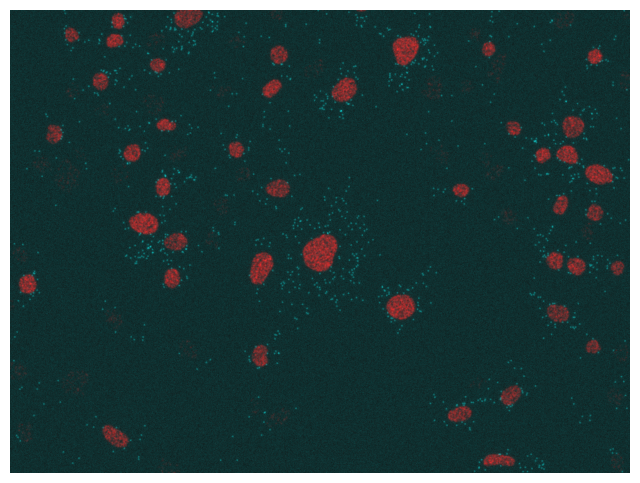

In [5]:
overlay(image=[image_nuclear, image_spots])

In [6]:
print(df_spots[['y', 'x']])

         y     x
0       92   136
1       37   125
2       86   140
3       43   121
4       52   154
...    ...   ...
1173  1036  1161
1174  1026  1187
1175  1019  1197
1176  1010   509
1177  1010   472

[1178 rows x 2 columns]


(<Figure size 800x800 with 1 Axes>, <Axes: >)

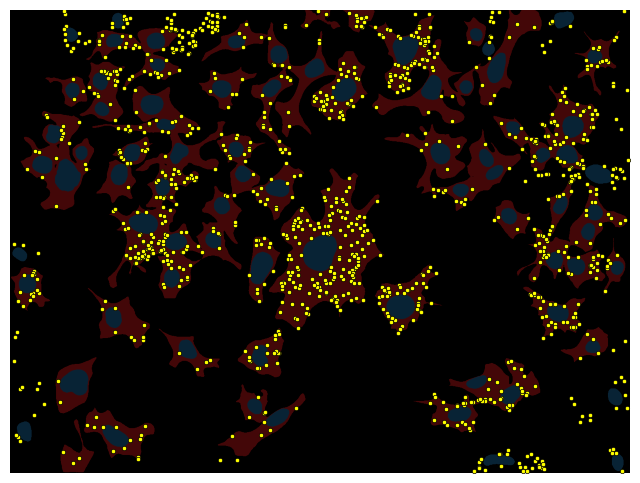

In [7]:
overlay(label_mask=[mask_cell, mask_nucleus], coordinates=df_spots[['y', 'x']].to_numpy())

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

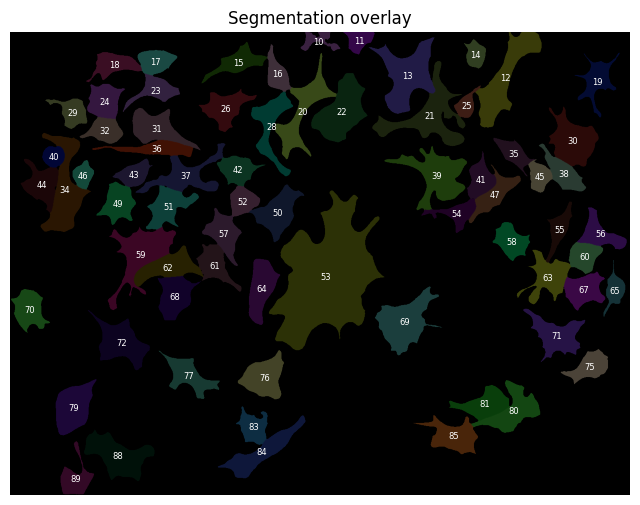

In [8]:
overlay(label_mask=mask_cell)

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

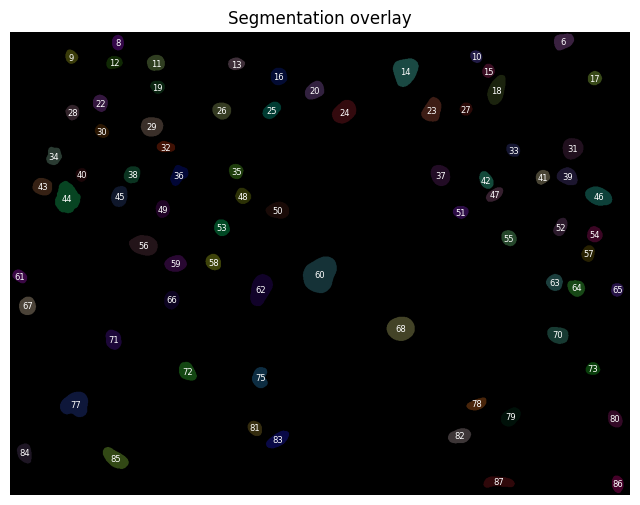

In [9]:
overlay(label_mask=mask_nucleus)

## Create DataFrame for cells
First, we generate a dataframe that contains all cells. We do this using the `regionprops_table` fucntion.

In [10]:
properties = [
    "area",
    "label"

]
props = skimage.measure.regionprops_table(
    mask_cell,  
    properties=properties
)

df_cell = pd.DataFrame(props)
print(df_cell)

       area  label
0    1835.0     10
1    2252.0     11
2   11083.0     12
3   11811.0     13
4    2201.0     14
..      ...    ...
65   3711.0     83
66   6932.0     84
67   6111.0     85
68   9146.0     88
69   3786.0     89

[70 rows x 2 columns]


That was simple. This table now contains all labels of the cells.

## Classify nuclei
Now, we classify the each nucleus' expression levels of the nuclear marker into *on* and *off*.
For that we use the label mask of the nuclei, the nuclear expression image and the `regionpros_table` function.

### Measure properties

In [11]:
properties = [
    "area",
    "intensity_mean",
    "label"
]
props = skimage.measure.regionprops_table(
    mask_nucleus, intensity_image=image_nuclear, properties=properties
)

df_nuc = pd.DataFrame(props)
print(df_nuc)

      area  intensity_mean  label
0   1377.0     6591.146696      6
1    796.0    30661.822864      8
2    744.0    25821.069892      9
3    643.0     6733.486781     10
4   1222.0     5673.916530     11
..     ...             ...    ...
72  1372.0     6305.796647     83
73  1219.0     6472.525021     84
74  1872.0    25275.821047     85
75   868.0     6763.014977     86
76  1472.0    29915.608696     87

[77 rows x 3 columns]


Let's add an `image_id` for book keeping.

In [12]:
df_nuc['image_id'] = image_nuclear_path.stem.split('_ch')[0]
print(df_nuc)

      area  intensity_mean  label image_id
0   1377.0     6591.146696      6  F01_837
1    796.0    30661.822864      8  F01_837
2    744.0    25821.069892      9  F01_837
3    643.0     6733.486781     10  F01_837
4   1222.0     5673.916530     11  F01_837
..     ...             ...    ...      ...
72  1372.0     6305.796647     83  F01_837
73  1219.0     6472.525021     84  F01_837
74  1872.0    25275.821047     85  F01_837
75   868.0     6763.014977     86  F01_837
76  1472.0    29915.608696     87  F01_837

[77 rows x 4 columns]


### Classify by intensity
To understand where we should set our threshold for *on* / *off*, we can plot the intensity measurements as a histogram.

<Axes: xlabel='intensity_mean', ylabel='Count'>

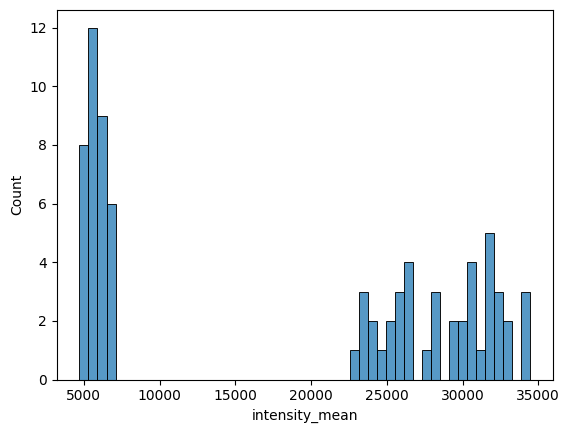

In [13]:
sns.histplot(
    data=df_nuc,
    x='intensity_mean',
    bins=50,
)

It seems like the expression is truly bimodal and 15,000 would be a good threshold. 

Now, we classify the intesity of nuclei using the `cut` function as before.

In [14]:
df_nuc['expression'] = pd.cut(df_nuc['intensity_mean'], bins=[0, 15000, np.inf], labels=['off', 'on']) 
print(df_nuc['expression'].unique()) 

['off', 'on']
Categories (2, object): ['off' < 'on']


/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_97289/452572658.py:115: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[measurement_col]) or pd.api.types.is_object_dtype(df[measurement_col]):
/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_97289/452572658.py:146: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[measurement_col]) or pd.api.types.is_object_dtype(df[measurement_col]):


(<Figure size 800x800 with 1 Axes>, <Axes: title={'center': 'expression'}>)

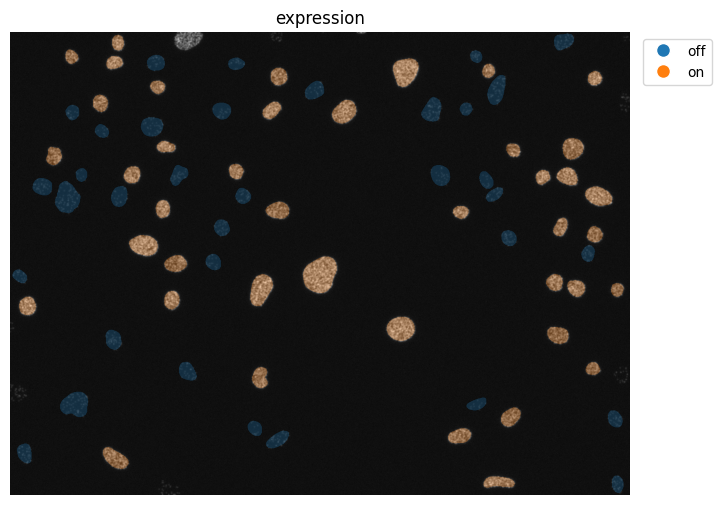

In [15]:
overlay(image=image_nuclear, label_mask=mask_nucleus, df=df_nuc, id_col='label', measurement_col='expression')

In [16]:
print(df_nuc)

      area  intensity_mean  label image_id expression
0   1377.0     6591.146696      6  F01_837        off
1    796.0    30661.822864      8  F01_837         on
2    744.0    25821.069892      9  F01_837         on
3    643.0     6733.486781     10  F01_837        off
4   1222.0     5673.916530     11  F01_837        off
..     ...             ...    ...      ...        ...
72  1372.0     6305.796647     83  F01_837        off
73  1219.0     6472.525021     84  F01_837        off
74  1872.0    25275.821047     85  F01_837         on
75   868.0     6763.014977     86  F01_837        off
76  1472.0    29915.608696     87  F01_837         on

[77 rows x 5 columns]


Great! Now we have a DataFrame where each nucleus is classified as expressing or non-expressing.

## Connecting the DataFrames
We now have three DataFrames:
* `df_cell` stores information about the cells, like their area and label
* `df_nuc` stores information about the nuclei, including the expression status
* `df_spots` stores the coordinates of the spots

We want to connect information about the nucleus (*on*/*off*) with informatin about the spots (how many/per cell). Both of these are properties of the cell, which makes it our central object. Another way of looking at this is that the cell is the unifying object that contains both the nucleus (and its expression state) and all the dots. Dots and nuclei are not directly connected.

Practically, this means we need to create two columns in `df_cell`:
* `nuclear_expression`: that maps the expression classification of the nucleus to the cell
* `number_of_spots`: that contains how many spots exist in each cell

### Map nuclear expression
To map the expression of the nuclei to the cells, we need to know which nuclear label corresponds to which cell label. As we can see below, they are not identical.

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

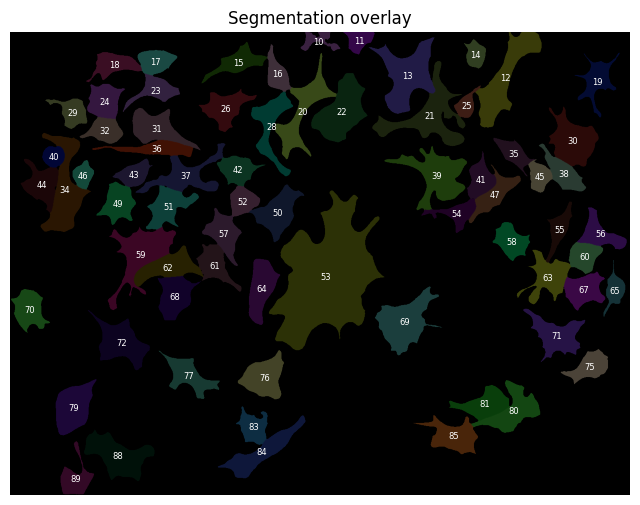

In [17]:
overlay(label_mask=mask_cell)

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

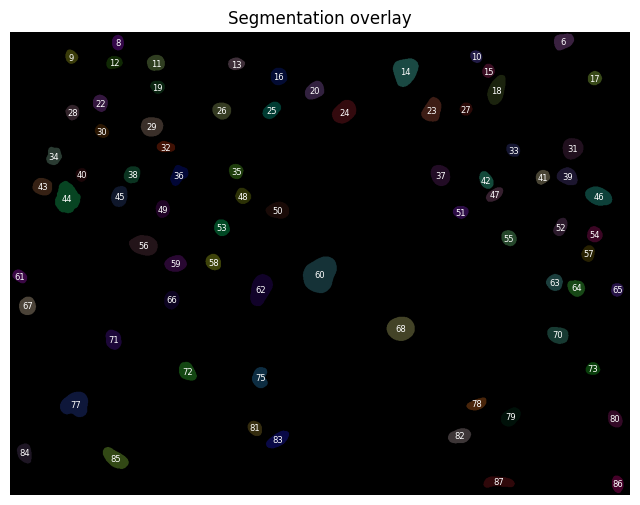

In [18]:
overlay(label_mask=mask_nucleus)

We can use regionprops_table to measure identify the cell label of each nucleus.

In [19]:
properties = [
    "intensity_mean",
    "label"
]
labels = skimage.measure.regionprops_table(
    mask_nucleus, intensity_image=mask_cell, properties=properties
)

df_merge = pd.DataFrame(labels)
df_merge = df_merge.rename({'intensity_mean':'label_cell'}, axis=1)
print(df_merge)

    label_cell  label
0          0.0      6
1          0.0      8
2          0.0      9
3         14.0     10
4         17.0     11
..         ...    ...
72        84.0     83
73         0.0     84
74        88.0     85
75         0.0     86
76         0.0     87

[77 rows x 2 columns]


In [20]:
df_nuc = df_nuc.merge(df_merge, on='label', how='left')
print(df_nuc)

      area  intensity_mean  label image_id expression  label_cell
0   1377.0     6591.146696      6  F01_837        off         0.0
1    796.0    30661.822864      8  F01_837         on         0.0
2    744.0    25821.069892      9  F01_837         on         0.0
3    643.0     6733.486781     10  F01_837        off        14.0
4   1222.0     5673.916530     11  F01_837        off        17.0
..     ...             ...    ...      ...        ...         ...
72  1372.0     6305.796647     83  F01_837        off        84.0
73  1219.0     6472.525021     84  F01_837        off         0.0
74  1872.0    25275.821047     85  F01_837         on        88.0
75   868.0     6763.014977     86  F01_837        off         0.0
76  1472.0    29915.608696     87  F01_837         on         0.0

[77 rows x 6 columns]


In [21]:
mapping = df_nuc.loc[df_nuc['label_cell'] != 0].drop_duplicates('label_cell', keep=False)[['label_cell', 'expression']]
mapping

,label_cell,expression
3,14.0,off
4,17.0,off
5,18.0,on
6,15.0,off
7,13.0,on
...,...,...
68,80.0,on
70,83.0,off
71,85.0,on
72,84.0,off


In [22]:
df_cell = df_cell.merge(mapping, left_on='label', right_on='label_cell', how='inner').drop(columns='label_cell')
print(df_cell)


       area  label expression
0   11083.0     12        off
1   11811.0     13         on
2    2201.0     14        off
3    4385.0     15        off
4    3136.0     16         on
..      ...    ...        ...
62   5343.0     81        off
63   3711.0     83        off
64   6932.0     84        off
65   6111.0     85         on
66   9146.0     88         on

[67 rows x 3 columns]


/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_97289/452572658.py:115: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[measurement_col]) or pd.api.types.is_object_dtype(df[measurement_col]):
/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_97289/452572658.py:146: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[measurement_col]) or pd.api.types.is_object_dtype(df[measurement_col]):


(<Figure size 800x800 with 1 Axes>, <Axes: title={'center': 'expression'}>)

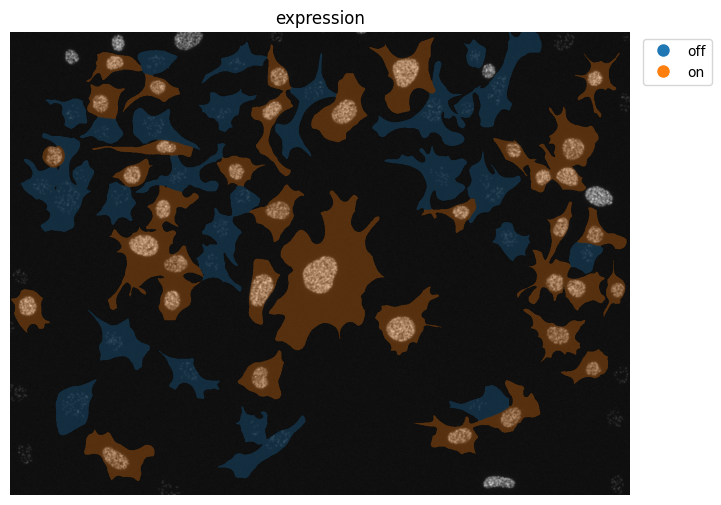

In [23]:
overlay(image=image_nuclear, label_mask=mask_cell, df=df_cell, id_col='label', measurement_col='expression')

### Map spot count
Now we applyt the same strategy to map the number of spots to `df_cell`. 
* Per spot, identify which cell it belongs to
* Count the number of spots per cell
* Add that information to the cell dataframe

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

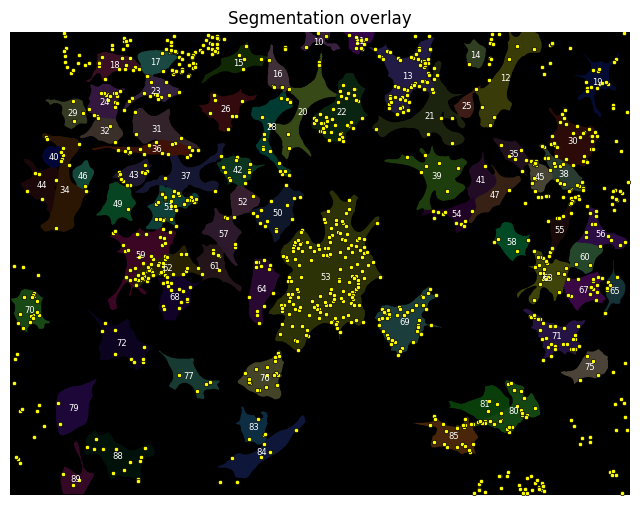

In [24]:
overlay(label_mask=mask_cell, coordinates=df_spots[['y', 'x']].to_numpy())

For each spot in `df_spots` we look up the cell label in `mask_cell`. 

In [25]:
df_spots['label_cell'] = mask_cell[df_spots['y'].astype(int), df_spots['x'].astype(int)]
print(df_spots['label_cell'].unique())


[ 0 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 28 29 30 31 32 34
 35 36 37 38 39 40 41 42 43 44 45 46 47 49 50 51 52 53 54 55 56 57 58 59
 60 61 62 63 64 65 67 68 69 70 71 72 75 76 77 79 80 81 83 84 85 88 89]


Now we count the number of spots per `cell_label`.

<Axes: xlabel='label_cell', ylabel='Count'>

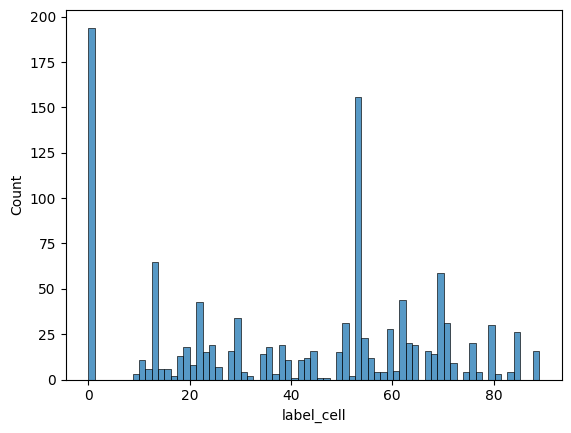

In [26]:
sns.histplot(
    data=df_spots,
    x='label_cell',
    bins=len(df_spots['label_cell'].unique())
)

Remove spots with `cell_label == 0`. Those spots are outside of valid cells.

In [27]:
df_spots = df_spots.loc[df_spots['label_cell'] != 0]
print(df_spots)

      channel     y    x  label_cell
98          1     2  691          10
99          1    33  664          10
100         1    10  710          10
101         1    19  791          11
102         1    16  799          11
...       ...   ...  ...         ...
1143        1  1003  288          88
1144        1  1008  288          88
1145        1  1006  154          89
1146        1  1017  140          89
1147        1   992  119          89

[984 rows x 4 columns]


Now we count the spots per cell, I.e., per unique `label_cell`.

In [28]:
mapping = df_spots['label_cell'].value_counts().reset_index()
print(mapping)

    label_cell  count
0           53    156
1           13     65
2           69     44
3           62     44
4           22     43
..         ...    ...
65          46      1
66          41      1
67          25      1
68          14      1
69          47      1

[70 rows x 2 columns]


Now we merge these measurements with `df_cell`.

In [29]:
df_cell = df_cell.merge(mapping, left_on='label', right_on='label_cell', how='inner').drop(columns='label_cell')
print(df_cell)

       area  label expression  count
0   11083.0     12        off      6
1   11811.0     13         on     65
2    2201.0     14        off      1
3    4385.0     15        off      5
4    3136.0     16         on      6
..      ...    ...        ...    ...
62   5343.0     81        off      3
63   3711.0     83        off      4
64   6932.0     84        off      5
65   6111.0     85         on     21
66   9146.0     88         on     13

[67 rows x 4 columns]


<Axes: xlabel='count', ylabel='Count'>

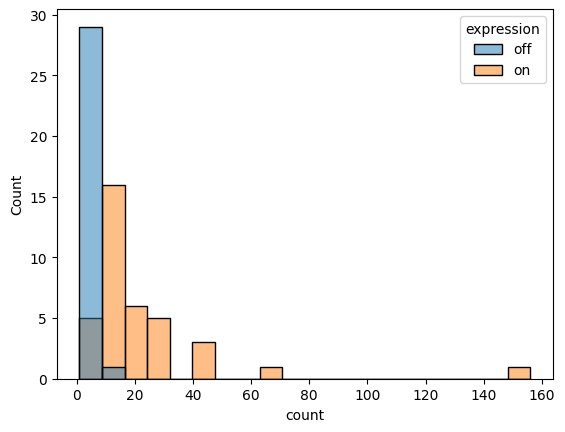

In [30]:
sns.histplot(
    data=df_cell,
    x='count',
    bins=20,
    hue='expression',
)

/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_97289/452572658.py:115: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[measurement_col]) or pd.api.types.is_object_dtype(df[measurement_col]):
/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_97289/452572658.py:146: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[measurement_col]) or pd.api.types.is_object_dtype(df[measurement_col]):


(<Figure size 800x800 with 2 Axes>, <Axes: title={'center': 'count'}>)

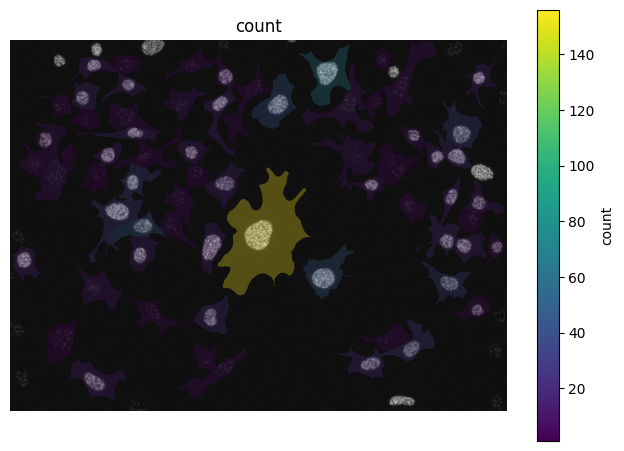

In [31]:
overlay(image=image_nuclear, label_mask=mask_cell, df=df_cell, id_col='label', measurement_col='count')

## Normalisation
We can see from the overlay above that the largest cell also has the most spots. This might be a case of size and number of spots being confunding variables; larger cells have more space and therefore more spots. Let's normalise the spot count by area.

In [32]:
df_cell['spot_count_norm'] = df_cell['count'] / df_cell['area']
print(df_cell['spot_count_norm'])

0     0.000541
1     0.005503
2     0.000454
3     0.001140
4     0.001913
        ...   
62    0.000561
63    0.001078
64    0.000721
65    0.003436
66    0.001421
Name: spot_count_norm, Length: 67, dtype: float64


/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_97289/452572658.py:115: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[measurement_col]) or pd.api.types.is_object_dtype(df[measurement_col]):
/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_97289/452572658.py:146: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[measurement_col]) or pd.api.types.is_object_dtype(df[measurement_col]):


(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'spot_count_norm'}>)

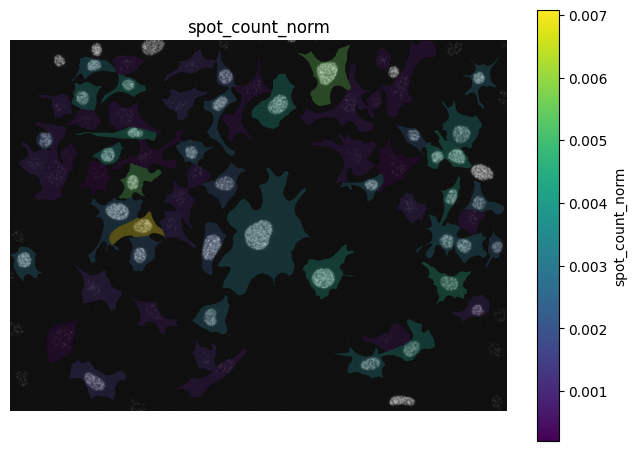

In [33]:
overlay(image=image_nuclear, label_mask=mask_cell, df=df_cell, id_col='label', measurement_col='spot_count_norm')

<Axes: xlabel='spot_count_norm', ylabel='Count'>

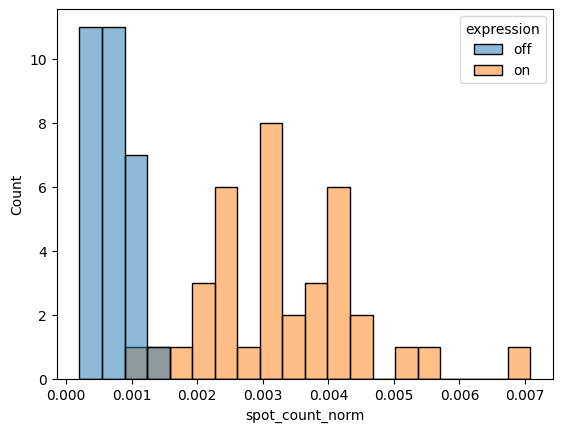

In [34]:
sns.histplot(
    data=df_cell,
    x='spot_count_norm',
    bins=20,
    hue='expression'
)

The picture is much clearer now.

## Batch processing
Now we set up batch processing to analyse all the images in the folder.

In [35]:
image_folder = Path("../../_static/images/quant/02_nested_measurements/images/")
mask_folder  = Path("../../_static/images/quant/02_nested_measurements/masks/")
spot_folder  = Path("../../_static/images/quant/02_nested_measurements/spot_lists/")

nuclear_images = sorted(image_folder.glob("*_ch0_nuclear.tif"))

list_df = []

for nuclear_path in nuclear_images:
    image_id = nuclear_path.stem.split("_ch")[0]  # e.g. F01_837

    # load images, masks, and spot coordinates
    image_nuclear = tifffile.imread(nuclear_path)
    mask_cell     = tifffile.imread(mask_folder / f"{image_id}w1.TIF")
    mask_nucleus  = tifffile.imread(mask_folder / f"{image_id}w2.TIF")
    df_spots      = pd.read_csv(spot_folder / f"{image_id}_spots.csv")

    # remove objects touching the border
    mask_cell    = skimage.segmentation.clear_border(mask_cell)
    mask_nucleus = skimage.segmentation.clear_border(mask_nucleus)

    # --- cell dataframe ---
    df_cell = pd.DataFrame(skimage.measure.regionprops_table(
        mask_cell, properties=["area", "label"]
    ))

    # --- nucleus dataframe: measure and classify expression ---
    df_nuc = pd.DataFrame(skimage.measure.regionprops_table(
        mask_nucleus, intensity_image=image_nuclear,
        properties=["area", "intensity_mean", "label"]
    ))
    df_nuc["image_id"]   = image_id
    df_nuc["expression"] = pd.cut(df_nuc["intensity_mean"], bins=[0, 15000, np.inf], labels=["off", "on"])

    # --- map each nucleus to the cell it sits in ---
    df_merge = pd.DataFrame(skimage.measure.regionprops_table(
        mask_nucleus, intensity_image=mask_cell, properties=["intensity_mean", "label"]
    )).rename(columns={"intensity_mean": "label_cell"})

    df_nuc = df_nuc.merge(df_merge, on="label", how="left")

    mapping_expr = (
        df_nuc[df_nuc["label_cell"] != 0]
        .drop_duplicates("label_cell", keep=False)
        [["label_cell", "expression"]]
    )
    df_cell = (
        df_cell
        .merge(mapping_expr, left_on="label", right_on="label_cell", how="inner")
        .drop(columns="label_cell")
    )

    # --- count spots per cell ---
    df_spots["label_cell"] = mask_cell[df_spots["y"].astype(int), df_spots["x"].astype(int)]
    df_spots = df_spots.loc[df_spots["label_cell"] != 0]
    mapping_spots = df_spots["label_cell"].value_counts().reset_index()
    df_cell = (
        df_cell
        .merge(mapping_spots, left_on="label", right_on="label_cell", how="inner")
        .drop(columns="label_cell")
    )
    df_cell["spot_count_norm"] = df_cell["count"] / df_cell["area"]

    df_cell["image_id"] = image_id
    list_df.append(df_cell)

df_full = pd.concat(list_df, ignore_index=True)


/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_97289/3390080950.py:48: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  df_cell
/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_97289/3390080950.py:48: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  df_cell
/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_97289/3390080950.py:48: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  df_cell
/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_97289/3390080950.py:48: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  df_cell
/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_97289/3390080950.py:48: UserWarning: You are merging on int and float columns where the f

In [36]:
print(df_full)


       area  label expression  count  spot_count_norm  image_id
0    9515.0      7        off      7         0.000736  F01_1296
1    3140.0      8        off      1         0.000318  F01_1296
2    8611.0      9         on     49         0.005690  F01_1296
3    1978.0     10         on     10         0.005056  F01_1296
4    4599.0     11         on     27         0.005871  F01_1296
..      ...    ...        ...    ...              ...       ...
742  5713.0     83         on     61         0.010677   F01_972
743  2650.0     84         on      4         0.001509   F01_972
744  3695.0     88         on     17         0.004601   F01_972
745  3584.0     91         on     12         0.003348   F01_972
746  3458.0     93         on     19         0.005495   F01_972

[747 rows x 6 columns]


In [37]:
df_plot = df_full.groupby(['expression','image_id'])[['count', 'spot_count_norm']].mean().reset_index()
df_plot

/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_97289/4043656410.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot = df_full.groupby(['expression','image_id'])[['count', 'spot_count_norm']].mean().reset_index()


,expression,image_id,count,spot_count_norm
0,off,F01_1296,4.735294,0.000758
1,off,F01_1377,3.566667,0.000641
2,off,F01_1457,9.000000,0.000916
3,off,F01_1464,4.551724,0.000721
4,off,F01_1465,4.307692,0.000704
5,off,F01_1467,3.918367,0.000700
6,off,F01_1489,7.090909,0.000889
7,off,F01_837,3.766667,0.000668
8,off,F01_840,5.078947,0.000763
9,off,F01_884,4.952381,0.000793


(0.0, 47.86966666666667)

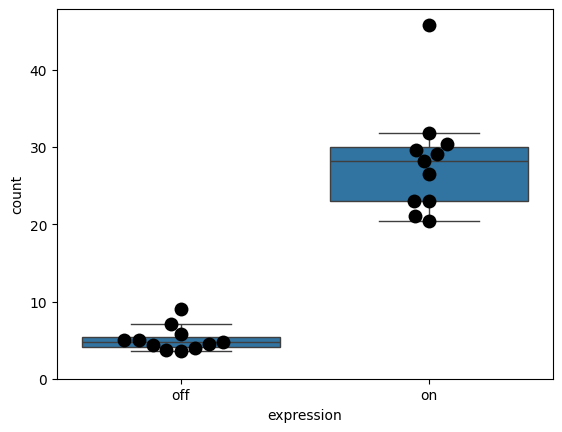

In [38]:
sns.boxplot(
    data=df_plot,
    x='expression',
    y='count',
)

sns.swarmplot(
    data=df_plot,
    x='expression',
    y='count',
    c='k', s=10
)
plt.ylim(0)

(0.0, 0.00472279472490316)

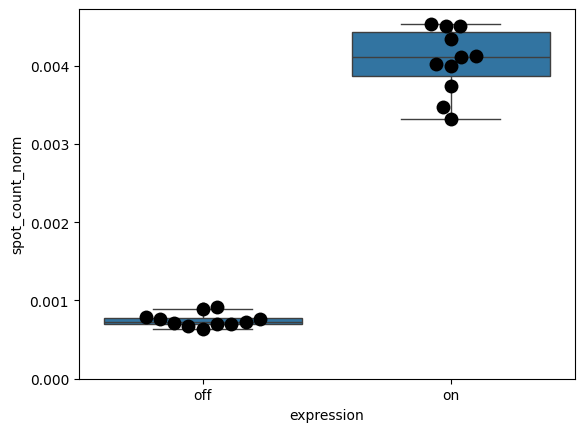

In [39]:
sns.boxplot(
    data=df_plot,
    x='expression',
    y='spot_count_norm',
)

sns.swarmplot(
    data=df_plot,
    x='expression',
    y='spot_count_norm',
    c='k', s=10
)
plt.ylim(0)

## Conclusion
We sucessfully integrated properties of different objects with each other. Handling these sort of nested measurements is a key aspect of analysing images.